# NYC 311 Data Overview

## Purpose

This notebook provides a structural overview of the raw NYC 311 service-request
extract used for the Urban Operations Intelligence Platform.

It examines dataset dimensions, columns, initial data types, date coverage,
agencies, complaint categories, descriptors, statuses, boroughs, intake
channels, location types, and complaint volume over time.

This notebook does not perform detailed cleaning, target creation, feature
engineering, data splitting, or modelling.

## API analysis boundary

The supplied NYC Open Data query is unfiltered and currently represents more
than twenty million records. Loading that complete JSON response into memory is
not appropriate for an overview notebook. This notebook therefore uses:

- full-dataset server-side aggregates for counts and categorical/time summaries;
- a deterministic, bounded sample of 1,000 records per creation year for
  row-level previews, pandas-inferred types, and lightweight completeness.

Every sample-derived result is labelled. The raw API values are preserved, and
the sample dataframe is never cleaned or overwritten.

## 1. Imports and display configuration

Only standard-library HTTP utilities, pandas, matplotlib, and notebook display
helpers are used. No packages are installed by this notebook.

In [1]:
from datetime import datetime, timezone
from http.client import RemoteDisconnected
from pathlib import Path
from urllib.error import HTTPError, URLError
from urllib.parse import urlencode
from urllib.request import Request, urlopen
import json
import socket
import sys
import time

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)

## 2. Project paths and API configuration

All output paths are project-relative. The report directories are created
idempotently so the notebook can be rerun without manual setup.

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from urban_ops.data.nyc_311_config import (
    API_ENDPOINT,
    API_MAX_ATTEMPTS,
    API_TIMEOUT_SECONDS,
    GROUP_RESULT_LIMIT,
    SAMPLE_ROWS_PER_YEAR,
    SELECTED_COLUMNS,
    SOURCE_API_URL,
    SOURCE_QUERY,
)
from urban_ops.utils.paths import (
    NOTEBOOK_PATH,
    ensure_report_directories,
    notebook_report_paths,
)

REPORT_DIR, REPORT_TABLES_DIR, REPORT_FIGURES_DIR = notebook_report_paths(
    "01_data_overview"
)
ensure_report_directories("01_data_overview")

PROJECT_ROOT, API_ENDPOINT, len(SELECTED_COLUMNS)

(PosixPath('/Users/mohammadmubashir/VCode/urban-operations-intelligence-platform'),
 'https://data.cityofnewyork.us/resource/erm2-nwe9.json',
 44)

## 3. Read-only API access

The helper below performs read-only GET requests with an explicit timeout and
bounded retries. It validates that the endpoint returned a JSON list. This is
not a production ingestion pipeline; it is the smallest reliable boundary
needed for this notebook.

In [3]:
def fetch_api_records(soql_query: str) -> list[dict[str, object]]:
    """Return records for a SoQL query with bounded retries and clear failures."""
    query_url = f"{API_ENDPOINT}?{urlencode({'$query': soql_query})}"
    request = Request(
        query_url,
        headers={
            "Accept": "application/json",
            "User-Agent": "urban-operations-intelligence-data-overview/1.0",
        },
    )
    last_error: Exception | None = None

    for attempt in range(1, API_MAX_ATTEMPTS + 1):
        try:
            with urlopen(request, timeout=API_TIMEOUT_SECONDS) as response:
                payload = json.load(response)
            if not isinstance(payload, list):
                raise RuntimeError("NYC Open Data returned JSON that was not a list.")
            return payload
        except (
            HTTPError,
            URLError,
            TimeoutError,
            socket.timeout,
            RemoteDisconnected,
            json.JSONDecodeError,
        ) as error:
            last_error = error
            if attempt < API_MAX_ATTEMPTS:
                time.sleep(2 ** (attempt - 1))

    raise RuntimeError(
        f"NYC Open Data request failed after {API_MAX_ATTEMPTS} attempts."
    ) from last_error


def fetch_group_summary(
    group_columns: list[str],
    output_names: list[str],
    total_row_count: int,
) -> pd.DataFrame:
    """Return a complete full-dataset group summary with readable missing labels."""
    group_expression = ", ".join(group_columns)
    query = (
        f"SELECT {group_expression}, count(*) AS record_count "
        f"GROUP BY {group_expression} "
        f"ORDER BY record_count DESC LIMIT {GROUP_RESULT_LIMIT}"
    )
    records = fetch_api_records(query)
    if len(records) >= GROUP_RESULT_LIMIT:
        raise RuntimeError(
            f"Grouped query reached its {GROUP_RESULT_LIMIT:,}-row safety limit."
        )

    source_frame = pd.DataFrame(records)
    summary = pd.DataFrame()
    for source_name, output_name in zip(group_columns, output_names, strict=True):
        if source_name in source_frame:
            summary[output_name] = source_frame[source_name].fillna("<MISSING>")
        else:
            summary[output_name] = "<MISSING>"

    summary["record_count"] = pd.to_numeric(
        source_frame["record_count"], errors="raise"
    ).astype("int64")
    summary["record_percentage"] = (
        summary["record_count"] / total_row_count * 100
    )
    return summary


def save_horizontal_bar_chart(
    summary: pd.DataFrame,
    label_column: str,
    title: str,
    output_path: Path,
    top_n: int | None = None,
) -> None:
    """Save a readable horizontal count chart from a descending summary table."""
    plot_frame = summary.head(top_n).sort_values("record_count")
    figure_height = max(4.5, min(12.0, len(plot_frame) * 0.42))
    figure, axis = plt.subplots(figsize=(11, figure_height))
    axis.barh(plot_frame[label_column].astype(str), plot_frame["record_count"])
    axis.set_title(title)
    axis.set_xlabel("Request count")
    axis.set_ylabel("")
    axis.grid(axis="x", alpha=0.25)
    figure.tight_layout()
    figure.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(figure)

## 4. Full-dataset scope and deterministic raw sample

The full row count and creation-date range come from a server-side aggregate.
For row-level inspection, the notebook retrieves the first 1,000 records in
stable creation-date and identifier order within each year. This spans the full
time range without pretending to be a statistically random sample.

In [4]:
scope_query = (
    "SELECT count(*) AS row_count, "
    "min(created_date) AS minimum_created_date, "
    "max(created_date) AS maximum_created_date"
)
scope_record = fetch_api_records(scope_query)[0]

total_row_count = int(scope_record["row_count"])
minimum_created_date = pd.to_datetime(scope_record["minimum_created_date"])
maximum_created_date = pd.to_datetime(scope_record["maximum_created_date"])

sample_records: list[dict[str, object]] = []
for sample_year in range(
    minimum_created_date.year,
    maximum_created_date.year + 1,
):
    next_year = sample_year + 1
    sample_query = (
        f"{SOURCE_QUERY} "
        f"WHERE created_date >= '{sample_year}-01-01T00:00:00' "
        f"AND created_date < '{next_year}-01-01T00:00:00' "
        "ORDER BY created_date, unique_key "
        f"LIMIT {SAMPLE_ROWS_PER_YEAR}"
    )
    sample_records.extend(fetch_api_records(sample_query))

df = pd.DataFrame(sample_records).reindex(columns=SELECTED_COLUMNS)
if df.empty:
    raise RuntimeError("The NYC Open Data API returned no records for inspection.")

retrieved_at_utc = datetime.now(timezone.utc)
len(df), total_row_count, minimum_created_date, maximum_created_date

(7000,
 21911249,
 Timestamp('2020-01-01 00:00:00'),
 Timestamp('2026-07-23 01:51:03'))

### Extraction metadata

The metadata records the source, retrieval time, full API scope, and bounded
row-level sampling strategy. The raw sample remains unchanged after this cell.

In [5]:
extraction_metadata = pd.DataFrame(
    [
        {
            "source_endpoint": API_ENDPOINT,
            "source_query": SOURCE_QUERY,
            "retrieved_at_utc": retrieved_at_utc.isoformat(),
            "full_dataset_row_count": total_row_count,
            "full_dataset_minimum_created_date": minimum_created_date.isoformat(),
            "full_dataset_maximum_created_date": maximum_created_date.isoformat(),
            "row_level_sample_count": len(df),
            "sampling_strategy": (
                f"First {SAMPLE_ROWS_PER_YEAR:,} rows per creation year, "
                "ordered by created_date and unique_key"
            ),
        }
    ]
)
extraction_metadata.to_csv(
    REPORT_TABLES_DIR / "api_extraction_metadata.csv",
    index=False,
)
extraction_metadata.T

,0
source_endpoint,https://data.cityofnewyork.us/resource/erm2-nwe9.json
source_query,"SELECT unique_key, created_date, closed_date, agency, agency_name, complaint_type, descriptor, descriptor_2, locatio..."
retrieved_at_utc,2026-07-24T07:37:49.374918+00:00
full_dataset_row_count,21911249
full_dataset_minimum_created_date,2020-01-01T00:00:00
full_dataset_maximum_created_date,2026-07-23T01:51:03
row_level_sample_count,7000
sampling_strategy,"First 1,000 rows per creation year, ordered by created_date and unique_key"


## 5. Dataset dimensions

The API dataset row count is exact at retrieval time. Because the complete JSON
dataset is not loaded, memory usage is an estimate derived from the bounded
sample's deep pandas memory usage. The loaded-sample size is reported
separately.

In [6]:
sample_memory_usage_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
estimated_full_memory_usage_mb = (
    sample_memory_usage_mb / len(df) * total_row_count
)

dataset_overview = pd.DataFrame(
    [
        {
            "row_count": total_row_count,
            "column_count": len(SELECTED_COLUMNS),
            "memory_usage_mb": round(estimated_full_memory_usage_mb, 2),
            "loaded_sample_row_count": len(df),
            "loaded_sample_memory_usage_mb": round(sample_memory_usage_mb, 2),
            "memory_measurement_basis": "Estimated from deterministic API sample",
        }
    ]
)
dataset_overview.to_csv(
    REPORT_TABLES_DIR / "dataset_overview.csv",
    index=False,
)
dataset_overview

,row_count,column_count,memory_usage_mb,loaded_sample_row_count,loaded_sample_memory_usage_mb,memory_measurement_basis
0,21911249,44,55610.53,7000,17.77,Estimated from deterministic API sample


## 6. Dataset grain

Each returned row appears to represent one NYC 311 service request.
The API field **unique_key** appears to be the complaint identifier. Formal
uniqueness validation is intentionally deferred to
**02_schema_and_quality_analysis.ipynb**.

In [7]:
df.head(3)

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,incident_address,street_name,cross_street_1,cross_street_2,intersection_street_1,intersection_street_2,address_type,city,landmark,facility_type,status,due_date,resolution_description,resolution_action_updated_date,community_board,council_district,police_precinct,bbl,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
0,45285347,2020-01-01T00:00:00.000,2020-01-10T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,3 or More,NaN,Restaurant/Bar/Deli/Bakery,11229,3442 NOSTRAND AVENUE,NOSTRAND AVENUE,GRAVESEND NECK ROAD,AVENUE V,GRAVESEND NECK ROAD,AVENUE V,ADDRESS,BROOKLYN,NOSTRAND AVENUE,NaN,Closed,NaN,The Health Departmentâs Office of Environmental Investigations has determined this case was an isolated incident. ...,2020-01-10T16:38:17.000,15 BROOKLYN,46,Precinct 61,3073620008,BROOKLYN,1000400,157925,ONLINE,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.6001292057807,-73.94184291675883,"{'type': 'Point', 'coordinates': [-73.941842916759, 40.600129205781]}"
1,45285651,2020-01-01T00:00:00.000,2020-01-02T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,NaN,Restaurant/Bar/Deli/Bakery,10458,2701 DECATUR AVENUE,DECATUR AVENUE,EAST 195 STREET,EAST 197 STREET,EAST 195 STREET,EAST 197 STREET,ADDRESS,BRONX,DECATUR AVENUE,NaN,Closed,NaN,The Department of Health and Mental Hygiene has determined that the reported incident is isolated. The establishmen...,2020-01-15T16:43:53.000,07 BRONX,15,Precinct 52,2032830055,BRONX,1015012,254391,PHONE,Unspecified,BRONX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.86486556770799,-73.88878325729915,"{'type': 'Point', 'coordinates': [-73.888783257299, 40.864865567708]}"
2,45285821,2020-01-01T00:00:00.000,2020-01-02T09:50:09.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,NaN,Other (Explain Below),11203,5707 CHURCH AVENUE,CHURCH AVENUE,EAST 57 STREET,KINGS HIGHWAY,EAST 57 STREET,KINGS HIGHWAY,ADDRESS,BROOKLYN,CHURCH AVENUE,NaN,Closed,NaN,The Health Departmentâs Office of Environmental Investigations has determined this case was an isolated incident. ...,2020-01-02T09:50:00.000,17 BROOKLYN,41,Precinct 67,NaN,BROOKLYN,1005466,177022,ONLINE,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.65253575905768,-73.92353994017134,"{'type': 'Point', 'coordinates': [-73.923539940171, 40.652535759058]}"


## 7. Column inventory

The API uses snake_case field names rather than the display labels used by CSV
exports. No raw dataframe columns are renamed.

In [8]:
column_inventory = pd.DataFrame(
    {
        "column_position": range(1, len(SELECTED_COLUMNS) + 1),
        "column_name": SELECTED_COLUMNS,
    }
)
column_inventory.to_csv(
    REPORT_TABLES_DIR / "column_inventory.csv",
    index=False,
)
column_inventory

,column_position,column_name
0,1,unique_key
1,2,created_date
2,3,closed_date
3,4,agency
4,5,agency_name
5,6,complaint_type
6,7,descriptor
7,8,descriptor_2
8,9,location_type
9,10,incident_zip


## 8. Initial pandas-inferred data types

A JSON or CSV source does not provide a strict pandas schema. Pandas infers
types from observed values in the bounded raw sample. The table below therefore
reports the **Initial pandas-inferred data type**, not the definitive business
type.

For example, created_date may be loaded as object while logically representing
a datetime; incident_zip and unique_key are identifiers even when they look
numeric; agency, status, and borough are categorical strings; latitude and
longitude are continuous geographic coordinates; and due_date can have an
unreliable inferred type when values are absent.

In [9]:
raw_dtype_summary = pd.DataFrame(
    {
        "column_name": df.columns,
        "apparent_pandas_dtype": [str(dtype) for dtype in df.dtypes],
    }
)
raw_dtype_summary.to_csv(
    REPORT_TABLES_DIR / "raw_dtype_summary.csv",
    index=False,
)
raw_dtype_summary

,column_name,apparent_pandas_dtype
0,unique_key,str
1,created_date,str
2,closed_date,str
3,agency,str
4,agency_name,str
5,complaint_type,str
6,descriptor,str
7,descriptor_2,str
8,location_type,str
9,incident_zip,str


## 9. Logical data-type interpretation

This explanatory table distinguishes observed pandas types from likely logical
business types. It does not convert the raw dataframe.

In [10]:
logical_type_definitions = [
    ("unique_key", "identifier", "complaint identifier", "Treat as an identifier, not a quantity."),
    ("created_date", "datetime", "request creation time", "Available at prediction time."),
    ("closed_date", "datetime", "post-outcome timestamp", "Potential leakage; unavailable for new requests."),
    ("due_date", "datetime", "resolution target timestamp", "Completeness and validity require later analysis."),
    ("agency", "categorical string", "responding agency code", "Bounded operational category."),
    ("agency_name", "categorical string", "responding agency name", "Human-readable agency label."),
    ("complaint_type", "categorical string", "complaint category", "CSV display label may differ."),
    ("descriptor", "categorical string", "complaint detail", "Detailed problem description category."),
    ("descriptor_2", "categorical string", "secondary complaint detail", "Additional API-native detail field."),
    ("status", "categorical string", "request state", "May include unresolved states."),
    ("incident_zip", "postal-code string", "geographic identifier", "Leading zeroes must remain meaningful."),
    ("borough", "categorical string", "geographic borough", "Missing and non-standard values need later review."),
    ("open_data_channel_type", "categorical string", "intake channel", "How the request entered NYC 311."),
    ("location_type", "categorical string", "location category", "Operational location context."),
    ("latitude", "geographic coordinate", "latitude", "Continuous numeric coordinate when present."),
    ("longitude", "geographic coordinate", "longitude", "Continuous numeric coordinate when present."),
    ("resolution_description", "post-outcome text", "resolution narrative", "Potential leakage at prediction time."),
    (
        "resolution_action_updated_date",
        "datetime",
        "post-outcome timestamp",
        "Potential leakage; sequence validity requires later analysis.",
    ),
]

logical_type_interpretation = pd.DataFrame(
    logical_type_definitions,
    columns=["column_name", "likely_logical_type", "business_role", "notes"],
)
logical_type_interpretation.insert(
    1,
    "pandas_inferred_type",
    logical_type_interpretation["column_name"].map(
        {column: str(dtype) for column, dtype in df.dtypes.items()}
    ),
)
logical_type_interpretation.to_csv(
    REPORT_TABLES_DIR / "logical_type_interpretation.csv",
    index=False,
)
logical_type_interpretation

,column_name,pandas_inferred_type,likely_logical_type,business_role,notes
0,unique_key,str,identifier,complaint identifier,"Treat as an identifier, not a quantity."
1,created_date,str,datetime,request creation time,Available at prediction time.
2,closed_date,str,datetime,post-outcome timestamp,Potential leakage; unavailable for new requests.
3,due_date,float64,datetime,resolution target timestamp,Completeness and validity require later analysis.
4,agency,str,categorical string,responding agency code,Bounded operational category.
5,agency_name,str,categorical string,responding agency name,Human-readable agency label.
6,complaint_type,str,categorical string,complaint category,CSV display label may differ.
7,descriptor,str,categorical string,complaint detail,Detailed problem description category.
8,descriptor_2,str,categorical string,secondary complaint detail,Additional API-native detail field.
9,status,str,categorical string,request state,May include unresolved states.


## 10. Representative records

The first table follows the deterministic per-year API sample order. The second
uses a fixed pandas random seed. A separate readable preview of selected fields
follows for easier inspection of one service-request record.

In [11]:
df.head(5)

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,incident_address,street_name,cross_street_1,cross_street_2,intersection_street_1,intersection_street_2,address_type,city,landmark,facility_type,status,due_date,resolution_description,resolution_action_updated_date,community_board,council_district,police_precinct,bbl,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
0,45285347,2020-01-01T00:00:00.000,2020-01-10T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,3 or More,NaN,Restaurant/Bar/Deli/Bakery,11229,3442 NOSTRAND AVENUE,NOSTRAND AVENUE,GRAVESEND NECK ROAD,AVENUE V,GRAVESEND NECK ROAD,AVENUE V,ADDRESS,BROOKLYN,NOSTRAND AVENUE,NaN,Closed,NaN,The Health Departmentâs Office of Environmental Investigations has determined this case was an isolated incident. ...,2020-01-10T16:38:17.000,15 BROOKLYN,46,Precinct 61,3073620008,BROOKLYN,1000400,157925,ONLINE,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.6001292057807,-73.94184291675883,"{'type': 'Point', 'coordinates': [-73.941842916759, 40.600129205781]}"
1,45285651,2020-01-01T00:00:00.000,2020-01-02T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,NaN,Restaurant/Bar/Deli/Bakery,10458,2701 DECATUR AVENUE,DECATUR AVENUE,EAST 195 STREET,EAST 197 STREET,EAST 195 STREET,EAST 197 STREET,ADDRESS,BRONX,DECATUR AVENUE,NaN,Closed,NaN,The Department of Health and Mental Hygiene has determined that the reported incident is isolated. The establishmen...,2020-01-15T16:43:53.000,07 BRONX,15,Precinct 52,2032830055,BRONX,1015012,254391,PHONE,Unspecified,BRONX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.86486556770799,-73.88878325729915,"{'type': 'Point', 'coordinates': [-73.888783257299, 40.864865567708]}"
2,45285821,2020-01-01T00:00:00.000,2020-01-02T09:50:09.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,NaN,Other (Explain Below),11203,5707 CHURCH AVENUE,CHURCH AVENUE,EAST 57 STREET,KINGS HIGHWAY,EAST 57 STREET,KINGS HIGHWAY,ADDRESS,BROOKLYN,CHURCH AVENUE,NaN,Closed,NaN,The Health Departmentâs Office of Environmental Investigations has determined this case was an isolated incident. ...,2020-01-02T09:50:00.000,17 BROOKLYN,41,Precinct 67,NaN,BROOKLYN,1005466,177022,ONLINE,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.65253575905768,-73.92353994017134,"{'type': 'Point', 'coordinates': [-73.923539940171, 40.652535759058]}"
3,45287907,2020-01-01T00:00:00.000,2020-01-02T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,3 or More,NaN,Restaurant/Bar/Deli/Bakery,11214,1602 SHORE PARKWAY,SHORE PARKWAY,BELT PARKWAY EXIT 5 EASTBOUND,BELT PARKWAY EB EN BAY PKWY,BELT PARKWAY EXIT 5 EASTBOUND,BELT PARKWAY EB EN BAY PKWY,ADDRESS,BROOKLYN,SHORE PARKWAY,NaN,Closed,NaN,The Department of Health and Mental Hygiene has determined that the reported incident is isolated. The establishmen...,2020-01-15T16:51:03.000,11 BROOKLYN,43,Precinct 62,3064910050,BROOKLYN,984202,156289,ONLINE,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.59565343138651,-74.00017283917487,"{'type': 'Point', 'coordinates': [-74.000172839175, 40.595653431387]}"
4,45288120,2020-01-01T00:00:00.000,2020-01-02T09:51:29.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,3 or More,NaN,Restaurant/Bar/Deli/Bakery,10455,748 EAST 149 STREET,EAST 149 STREET,CONCORD AVENUE,WALES AVENUE,CONCORD AVENUE,WALES AVENUE,ADDRESS,BRONX,EAST 149 STREET,NaN,Closed,NaN,The Department of Health and Mental Hygiene has determined that the reported incident is isolated. The establishmen...,2020-01-02T09:51:29.000,01 BRONX,08,Precinct 40,NaN,BRONX,1009724,235487,ONLINE,Unspecified,BRONX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.81299645614164,-73.90797324533352,"{'type': 'P

In [12]:
df.sample(n=5, random_state=42)

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,incident_address,street_name,cross_street_1,cross_street_2,intersection_street_1,intersection_street_2,address_type,city,landmark,facility_type,status,due_date,resolution_description,resolution_action_updated_date,community_board,council_district,police_precinct,bbl,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
6500,67349244,2026-01-01T00:59:59.000,2026-01-01T01:11:07.000,NYPD,New York City Police Department,Blocked Driveway,No Access,NaN,Street/Sidewalk,11208,902 BELMONT AVENUE,BELMONT AVENUE,LOGAN STREET,FOUNTAIN AVENUE,LOGAN STREET,FOUNTAIN AVENUE,ADDRESS,BROOKLYN,BELMONT AVENUE,NaN,Closed,NaN,The New York City Police Department responded to the complaint and their investigation determined that a violation o...,2026-01-01T01:11:09.000,05 BROOKLYN,42,Precinct 75,3042460021,BROOKLYN,1018778,184697,PHONE,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.673560016165396,-73.87552574863949,"{'type': 'Point', 'coordinates': [-73.875525748639, 40.673560016165]}"
2944,52936565,2022-01-01T01:48:30.000,2022-01-01T02:10:09.000,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,NaN,Street/Sidewalk,10026,265 WEST 114 STREET,WEST 114 STREET,ADAM CLAYTON POWELL JR BOULEVARD,FREDERICK DOUGLASS BOULEVARD,ADAM CLAYTON POWELL JR BOULEVARD,FREDERICK DOUGLASS BOULEVARD,ADDRESS,NEW YORK,WEST 114 STREET,NaN,Closed,NaN,The Police Department responded to the complaint and took action to fix the condition.,2022-01-01T02:10:12.000,10 MANHATTAN,09,Precinct 28,1018300011,MANHATTAN,996213,231952,MOBILE,Unspecified,MANHATTAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.80332248776049,-73.95678904346106,"{'type': 'Point', 'coordinates': [-73.956789043461, 40.80332248776]}"
2024,52933824,2022-01-01T00:05:14.000,2022-01-01T02:06:38.000,NYPD,New York City Police Department,Illegal Fireworks,N/A,NaN,Street/Sidewalk,11208,3429 ATLANTIC AVENUE,ATLANTIC AVENUE,HEMLOCK STREET,AUTUMN AVENUE,HEMLOCK STREET,AUTUMN AVENUE,ADDRESS,BROOKLYN,ATLANTIC AVENUE,NaN,Closed,NaN,The Police Department responded to the complaint and with the information available observed no evidence of the viol...,2022-01-01T02:06:46.000,05 BROOKLYN,37,Precinct 75,3041480067,BROOKLYN,1020245,187803,ONLINE,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.682079431383194,-73.8702205975783,"{'type': 'Point', 'coordinates': [-73.870220597578, 40.682079431383]}"
263,45288994,2020-01-01T01:01:40.000,2020-02-20T00:00:00.000,DOB,Department of Buildings,Elevator,Elevator - Multiple Devices On Property,NaN,NaN,10016,300 EAST 34 STREET,EAST 34 STREET,NaN,NaN,NaN,NaN,ADDRESS,NEW YORK,NaN,NaN,Closed,NaN,The Department of Buildings investigated this complaint and determined that no further action was necessary.,2020-02-20T00:00:00.000,06 MANHATTAN,02,Precinct 17,1009390001,MANHATTAN,990959,210603,UNKNOWN,Unspecified,MANHATTAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.744730633043375,-73.9757880681296,"{'type': 'Point', 'coordinates': [-73.97578806813, 40.744730633043]}"
4350,59887502,2024-01-01T00:40:12.000,2024-01-01T01:54:23.000,NYPD,New York City Police Department,Blocked Driveway,No Access,NaN,Street/Sidewalk,11221,119 GROVE STREET,GROVE STREET,EVERGREEN AVENUE,CENTRAL AVENUE,EVERGREEN AVENUE,CENTRAL AVENUE,ADDRESS,BROOKLYN,GROVE STREET,NaN,Closed,NaN,The Police Department responded to the complaint and with the information available observed no evidence of the viol...,2024-01-01T01:54:26.000,04 BROOKLYN,37,Precinct 83,3033140067,BROOKLYN,1006368,192039,PHONE,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.69375182760021,-73.92023995858511,"{'type': 'Point', 'coordinates': [-73.920239958585, 40.6937518276]}"


## Readable record preview

The full dataset contains many columns, so displaying every column for several
rows can be difficult to read.

The following preview selects representative fields that help explain what one
service-request record contains:

- complaint identifier;
- creation and closure timestamps;
- responsible agency;
- complaint category and descriptor;
- current status;
- expected due date;
- borough;
- submission channel.

This selection is only for display and readability. It is not a feature-selection
decision and does not imply that the remaining columns are unimportant.

All columns are still reviewed separately through the column inventory,
data-type summary, and completeness summary.

In [13]:
RECORD_PREVIEW_COLUMNS = [
    "unique_key",
    "created_date",
    "closed_date",
    "agency",
    "agency_name",
    "complaint_type",
    "descriptor",
    "status",
    "due_date",
    "borough",
    "open_data_channel_type",
]

missing_preview_columns = [
    column
    for column in RECORD_PREVIEW_COLUMNS
    if column not in df.columns
]

if missing_preview_columns:
    raise KeyError(
        "The following record preview columns are missing from the dataset: "
        f"{missing_preview_columns}"
    )

df.loc[:, RECORD_PREVIEW_COLUMNS].head(10)

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,status,due_date,borough,open_data_channel_type
0,45285347,2020-01-01T00:00:00.000,2020-01-10T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,3 or More,Closed,NaN,BROOKLYN,ONLINE
1,45285651,2020-01-01T00:00:00.000,2020-01-02T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,Closed,NaN,BRONX,PHONE
2,45285821,2020-01-01T00:00:00.000,2020-01-02T09:50:09.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,Closed,NaN,BROOKLYN,ONLINE
3,45287907,2020-01-01T00:00:00.000,2020-01-02T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,3 or More,Closed,NaN,BROOKLYN,ONLINE
4,45288120,2020-01-01T00:00:00.000,2020-01-02T09:51:29.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,3 or More,Closed,NaN,BRONX,ONLINE
5,45288240,2020-01-01T00:00:00.000,2020-01-02T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,Closed,NaN,QUEENS,ONLINE
6,45288728,2020-01-01T00:00:00.000,2020-01-02T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,Closed,NaN,BROOKLYN,ONLINE
7,45289555,2020-01-01T00:00:00.000,2020-01-02T09:39:33.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,Closed,NaN,QUEENS,ONLINE
8,45289558,2020-01-01T00:00:00.000,2020-01-15T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,3 or More,Closed,NaN,BROOKLYN,ONLINE
9,45282225,2020-01-01T00:01:12.000,2020-01-01T03:07:10.000,NYPD,New York City Police Department,Blocked Driveway,No Access,Closed,NaN,BROOKLYN,PHONE


## 11. Date overview

Temporary parsed Series support inspection without overwriting the API-native
raw columns. Full-dataset minimum, maximum, and completeness counts are computed
server-side. Detailed invalid-date parsing and timestamp-sequence validation are
deferred to **02_schema_and_quality_analysis.ipynb**.

In [14]:
DATE_COLUMNS = [
    "created_date",
    "closed_date",
    "due_date",
    "resolution_action_updated_date",
]
parsed_date_samples = {
    column: pd.to_datetime(df[column], errors="coerce")
    for column in DATE_COLUMNS
}

date_select_expressions = ["count(*) AS total_rows"]
for date_column in DATE_COLUMNS:
    date_select_expressions.extend(
        [
            f"min({date_column}) AS {date_column}_minimum",
            f"max({date_column}) AS {date_column}_maximum",
            f"count({date_column}) AS {date_column}_non_null",
        ]
    )

date_query = "SELECT " + ", ".join(date_select_expressions)
date_record = fetch_api_records(date_query)[0]
date_total_rows = int(date_record["total_rows"])

date_coverage_rows = []
for date_column in DATE_COLUMNS:
    non_null_count = int(date_record.get(f"{date_column}_non_null", 0))
    missing_count = date_total_rows - non_null_count
    date_coverage_rows.append(
        {
            "column": date_column,
            "minimum_date": date_record.get(f"{date_column}_minimum"),
            "maximum_date": date_record.get(f"{date_column}_maximum"),
            "non_null_count": non_null_count,
            "missing_count": missing_count,
            "missing_percentage": missing_count / date_total_rows * 100,
        }
    )

date_coverage = pd.DataFrame(date_coverage_rows)
date_coverage.to_csv(
    REPORT_TABLES_DIR / "date_coverage.csv",
    index=False,
)
date_coverage

,column,minimum_date,maximum_date,non_null_count,missing_count,missing_percentage
0,created_date,2020-01-01T00:00:00.000,2026-07-23T01:51:03.000,21911249,0,0.000000
1,closed_date,1899-12-31T19:00:00.000,2033-03-01T00:00:00.000,21496251,414998,1.893995
2,due_date,2018-09-29T09:26:39.000,2026-08-21T23:05:21.000,76953,21834296,99.648797
3,resolution_action_updated_date,2019-07-18T00:00:00.000,2026-12-14T11:50:00.000,21731449,179800,0.820583


## 12. Requests by creation year

These counts cover the complete API dataset, not the bounded row-level sample.
The latest year is labelled as partial when the maximum available creation date
falls before the end of that calendar year.

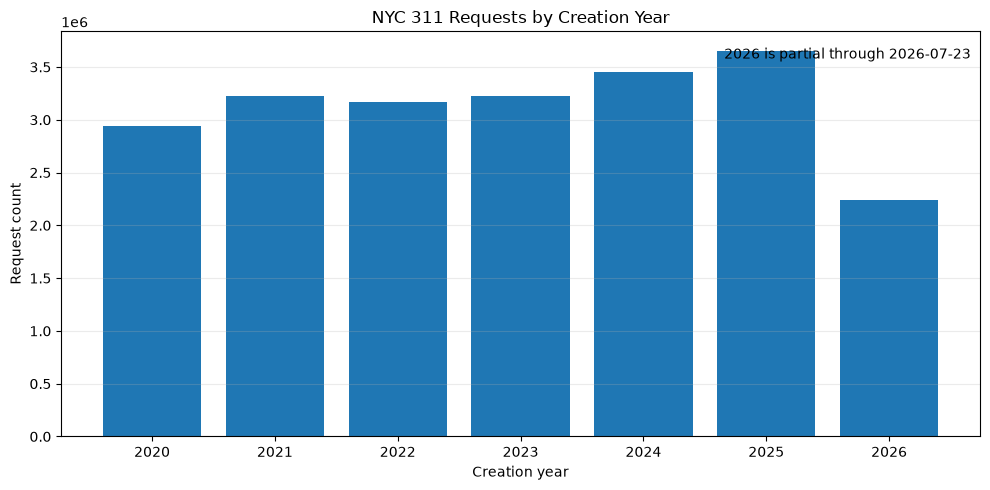

,creation_year,record_count
0,2020,2942024
1,2021,3220882
2,2022,3169960
3,2023,3224723
4,2024,3456770
5,2025,3655037
6,2026,2241853


In [15]:
year_query = (
    "SELECT date_extract_y(created_date) AS creation_year, "
    "count(*) AS record_count "
    "GROUP BY date_extract_y(created_date) "
    "ORDER BY creation_year"
)
records_by_year = pd.DataFrame(fetch_api_records(year_query))
records_by_year["creation_year"] = pd.to_numeric(
    records_by_year["creation_year"], errors="raise"
).astype("int64")
records_by_year["record_count"] = pd.to_numeric(
    records_by_year["record_count"], errors="raise"
).astype("int64")

latest_year_is_partial = maximum_created_date < pd.Timestamp(
    year=maximum_created_date.year,
    month=12,
    day=31,
    hour=23,
    minute=59,
    second=59,
)

figure, axis = plt.subplots(figsize=(10, 5))
axis.bar(records_by_year["creation_year"].astype(str), records_by_year["record_count"])
axis.set_title("NYC 311 Requests by Creation Year")
axis.set_xlabel("Creation year")
axis.set_ylabel("Request count")
axis.grid(axis="y", alpha=0.25)
if latest_year_is_partial:
    axis.text(
        0.99,
        0.96,
        (
            f"{maximum_created_date.year} is partial through "
            f"{maximum_created_date.date().isoformat()}"
        ),
        transform=axis.transAxes,
        ha="right",
        va="top",
    )
figure.tight_layout()
figure.savefig(
    REPORT_FIGURES_DIR / "records_by_year.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()
plt.close(figure)

records_by_year

## 13. Monthly request volume

Monthly counts also cover the full API dataset. The chart is descriptive only;
no anomaly detection is performed.

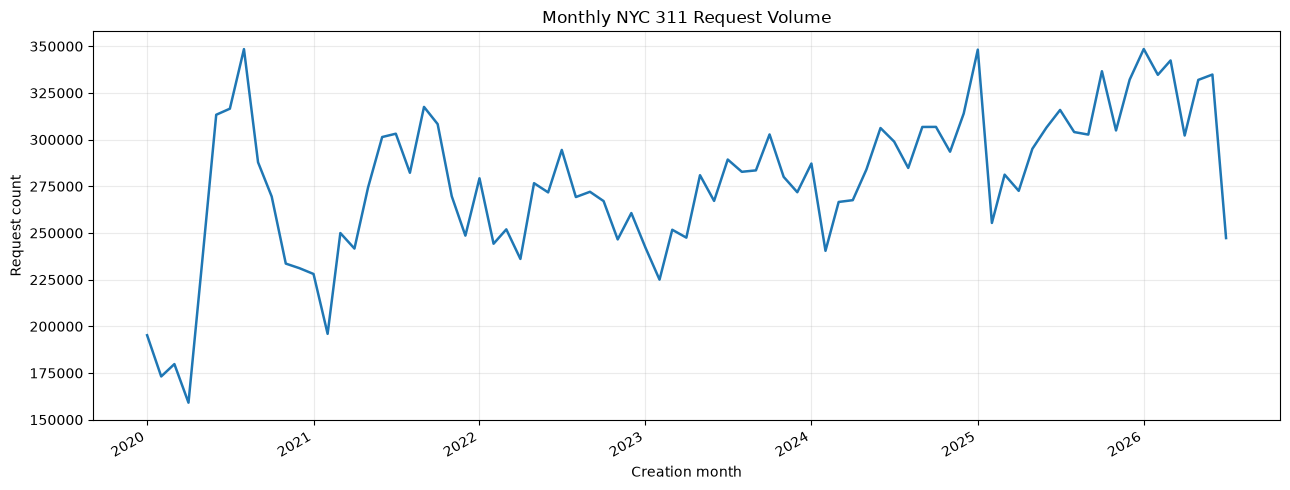

,creation_month,record_count
67,2025-08-01,304038
68,2025-09-01,302684
69,2025-10-01,336612
70,2025-11-01,304905
71,2025-12-01,332105
72,2026-01-01,348511
73,2026-02-01,334691
74,2026-03-01,342388
75,2026-04-01,302189
76,2026-05-01,331976


In [16]:
month_query = (
    "SELECT date_trunc_ym(created_date) AS creation_month, "
    "count(*) AS record_count "
    "GROUP BY date_trunc_ym(created_date) "
    "ORDER BY creation_month"
)
records_over_time = pd.DataFrame(fetch_api_records(month_query))
records_over_time["creation_month"] = pd.to_datetime(
    records_over_time["creation_month"],
    errors="raise",
)
records_over_time["record_count"] = pd.to_numeric(
    records_over_time["record_count"],
    errors="raise",
).astype("int64")

figure, axis = plt.subplots(figsize=(13, 5))
axis.plot(
    records_over_time["creation_month"],
    records_over_time["record_count"],
    linewidth=1.8,
)
axis.set_title("Monthly NYC 311 Request Volume")
axis.set_xlabel("Creation month")
axis.set_ylabel("Request count")
axis.grid(alpha=0.25)
figure.autofmt_xdate()
figure.tight_layout()
figure.savefig(
    REPORT_FIGURES_DIR / "records_over_time.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()
plt.close(figure)

records_over_time.tail(12)

## 14. Agency analysis

Agency counts are computed over the complete endpoint. The interpretation below
is generated from the observed result rather than assumed in advance.

In [17]:
agency_summary = fetch_group_summary(
    ["agency", "agency_name"],
    ["Agency", "Agency Name"],
    total_row_count,
)
agency_summary.to_csv(
    REPORT_TABLES_DIR / "agency_summary.csv",
    index=False,
)

agency_codes = agency_summary["Agency"].drop_duplicates().tolist()
if len(agency_codes) == 1 and agency_codes[0] == "DOT":
    agency_interpretation = (
        "The current extract contains only the Department of Transportation "
        "(DOT). It cannot support cross-agency comparison."
    )
else:
    agency_interpretation = (
        f"The endpoint contains {len(agency_codes):,} agency codes and is not "
        "restricted to DOT; cross-agency comparison is structurally possible, "
        "subject to later scope and quality decisions."
    )

display(Markdown(agency_interpretation))
agency_summary

The endpoint contains 21 agency codes and is not restricted to DOT; cross-agency comparison is structurally possible, subject to later scope and quality decisions.

,Agency,Agency Name,record_count,record_percentage
0,NYPD,New York City Police Department,9564905,43.652943
1,HPD,Department of Housing Preservation and Development,4352672,19.865011
2,DSNY,Department of Sanitation,2468804,11.267290
3,DOT,Department of Transportation,1468970,6.704182
4,DEP,Department of Environmental Protection,1161915,5.302824
5,DPR,Department of Parks and Recreation,826611,3.772542
6,DOB,Department of Buildings,639132,2.916913
7,DOHMH,Department of Health and Mental Hygiene,527971,2.409589
8,DHS,Department of Homeless Services,288546,1.316885
9,TLC,Taxi and Limousine Commission,196678,0.897612


## 15. Complaint-category analysis

The complete category list is saved and displayed. To keep the figure readable,
the chart shows the twenty categories with the largest record counts.

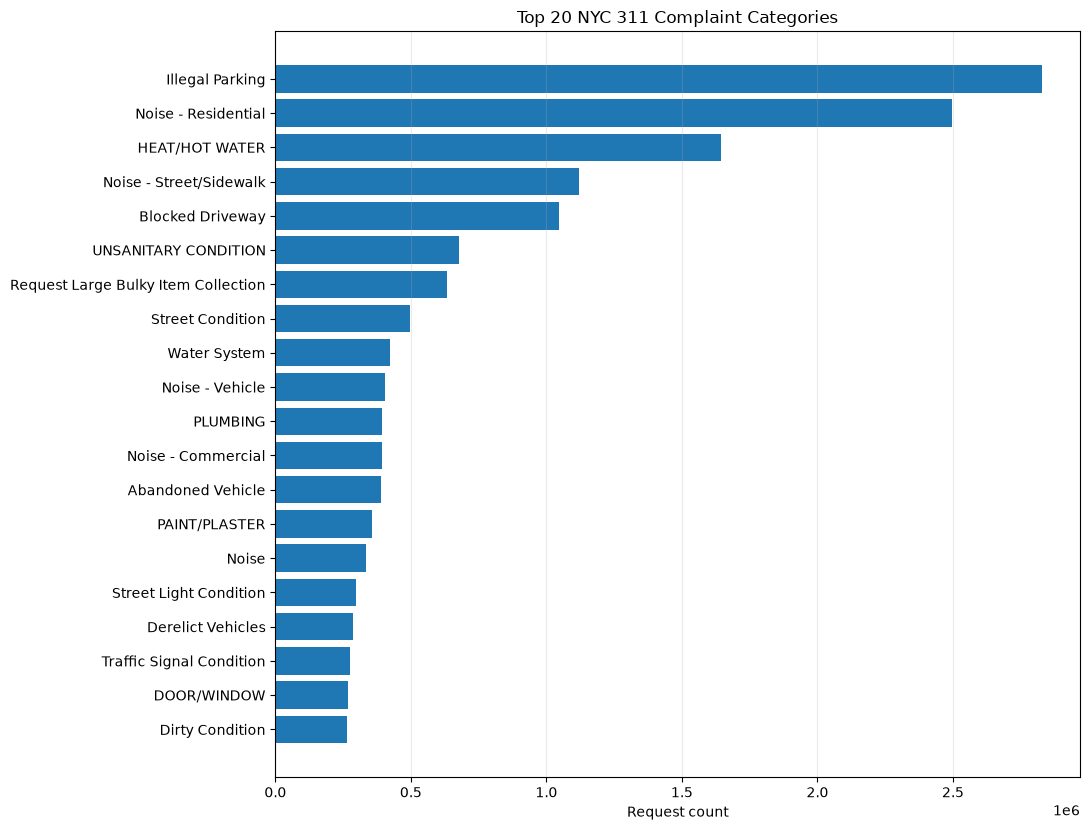

**Complaint categories found (272):** Illegal Parking, Noise - Residential, HEAT/HOT WATER, Noise - Street/Sidewalk, Blocked Driveway, UNSANITARY CONDITION, Request Large Bulky Item Collection, Street Condition, Water System, Noise - Vehicle, PLUMBING, Noise - Commercial, Abandoned Vehicle, PAINT/PLASTER, Noise, Street Light Condition, Derelict Vehicles, Traffic Signal Condition, DOOR/WINDOW, Dirty Condition, WATER LEAK, Damaged Tree, General Construction/Plumbing, Missed Collection, Rodent, Homeless Person Assistance, Encampment, Non-Emergency Police Matter, Sewer, GENERAL, Noise - Helicopter, ELECTRIC, Illegal Dumping, Sidewalk Condition, FLOORING/STAIRS, Consumer Complaint, Maintenance or Facility, APPLIANCE, Overgrown Tree/Branches, Building/Use, Illegal Fireworks, Elevator, For Hire Vehicle Complaint, Graffiti, New Tree Request, Drug Activity, Lead, Snow or Ice, Obstruction, Missed Collection (All Materials), Vendor Enforcement, SAFETY, Food Establishment, Dirty Conditions, NonCompliance with Phased Reopening, Dead/Dying Tree, Air Quality, Sanitation Condition, Root/Sewer/Sidewalk Condition, Residential Disposal Complaint, Noise - Park, Animal-Abuse, Panhandling, Dead Animal, Traffic, Indoor Air Quality, Taxi Complaint, Curb Condition, Lost Property, Street Sweeping Complaint, Broken Parking Meter, Street Sign - Damaged, Electronics Waste Appointment, Real Time Enforcement, Outdoor Dining, Animal in a Park, Violation of Park Rules, Illegal Tree Damage, Water Conservation, Street Sign - Missing, Mobile Food Vendor, Highway Condition, Special Projects Inspection Team (SPIT), Drinking, Street Sign - Dangling, Emergency Response Team (ERT), Boilers, Plumbing, Illegal Posting, Litter Basket Request, Food Poisoning, Smoking, Bike/Roller/Skate Chronic, Homeless Street Condition, Unsanitary Animal Pvt Property, Smoking or Vaping, Sanitation Worker or Vehicle Complaint, Electrical, Hazardous Materials, Other Enforcement, Noise - House of Worship, Commercial Disposal Complaint, ELEVATOR, Abandoned Bike, Day Care, Water Quality, Unleashed Dog, Snow, Asbestos, Dumpster Complaint, School Maintenance, Lot Condition, Standing Water, Unsanitary Pigeon Condition, Bus Stop Shelter Complaint, Urinating in Public, Vaccine Mandate Non-Compliance, COVID-19 Non-essential Construction, Litter Basket Complaint, Construction Lead Dust, Non-Residential Heat, OUTSIDE BUILDING, Industrial Waste, Overflowing Litter Baskets, Wood Pile Remaining, Taxi Report, Vending, Indoor Sewage, Vacant Lot, Litter Basket / Request, Investigations and Discipline (IAD), Mass Gathering Complaint, Cannabis Retailer, Illegal Animal Kept as Pet, Water Leak, Storm, Derelict Bicycle, Harboring Bees/Wasps, Sewer Maintenance, BEST/Site Safety, Snow Removal, Sweeping/Missed, For Hire Vehicle Report, Home Delivered Meal - Missed Delivery, Uprooted Stump, Mosquitoes, Paint/Plaster, Construction Safety Enforcement, E-Scooter, Private or Charter School Reopening, Mold, Ferry Inquiry, Bridge Condition, Drinking Water, Green Taxi Complaint, Heat/Hot Water, Face Covering Violation, Disorderly Youth, Ferry Complaint, Beach/Pool/Sauna Complaint, Unsanitary Condition, Door/Window, Bike/Roller/Skate, Tattooing, Bus Stop Shelter Placement, Bike Rack, LinkNYC, Scaffold Safety, Bike Rack Condition, Plant, Poison Ivy, Pet Shop, AHV Inspection Unit, Seasonal Collection, Adopt-A-Basket, Highway Sign - Damaged, Flooring/Stairs, DEP Street Condition, Recycling Enforcement, Posting Advertisement, General, Illegal Animal Sold, Animal Facility - No Permit, Unsanitary Animal Facility, Taxi Compliment, Cranes and Derricks, Appliance, Sweeping/Inadequate, Found Property, Collection Truck Noise, Recycling Basket Complaint, Public Payphone Complaint, Municipal Parking Facility, Water Maintenance, Incorrect Data, Highway Sign - Missing, Pet Sale, Special Natural Area District (SNAD), Safety, Electric, Institution Disposal Complaint, Building Drinking Water Tank, Public Toilet, Bench, Squeegee, Private School Vaccine Mandate Non-Compliance, Green Taxi Report, Tobacco or Non-Tobacco Sale, Special Operations, Homeless Encampment, Highway Sign - Dangling, Borough Office, Lifeguard, Dept of Investigations, Cooling Tower, X-Ray Machine/Equipment, Window Guard, Water Drainage, Peeling Paint, Radioactive Material, Unstable Building, Dispatched Taxi Complaint, Building Condition, Taxi Licensee Complaint, Sweeping/Missed-Inadequate, Bottled Water, Retailer Complaint, Calorie Labeling, FHV Licensee Complaint, SNW, Wayfinding, Transfer Station Complaint, Unspecified, Boiler, DEP Highway Condition, Oil or Gas Spill, Tunnel Condition, Building Marshal's Office, Miscellaneous Categories, Overflowing Recycling Baskets, DEP Sidewalk Condition, Internal Code, Tanning, Building Marshals office, DSNY Internal, Foam Ban Enforcement, Leaning Bar, Home Delivered Meal Complaint, Executive Inspections, ZTESTINT, DOB Posted Notice or Order, Ferry Permit, DSNY Spillage, SRDE, Employee Behavior, Trans Fat, Facades, SRGOVG, Dispatched Taxi Compliment, Electronics Waste, Facade Insp Safety Pgm, Unlicensed Dog, Outside Building, Stalled Sites, DEP Bridge Condition, Quality of Life, Trapping Pigeon, Change Collection Schedule, Forensic Engineering, ASBESTOS, MOLD, Sustainability Enforcement

,complaint_type,record_count,record_percentage
0,Illegal Parking,2827368,12.903728
1,Noise - Residential,2497831,11.399765
2,HEAT/HOT WATER,1645001,7.507564
3,Noise - Street/Sidewalk,1121349,5.117686
4,Blocked Driveway,1046241,4.774904
...,...,...,...
267,Change Collection Schedule,1,0.000005
268,Forensic Engineering,1,0.000005
269,ASBESTOS,1,0.000005
270,MOLD,1,0.000005


In [18]:
complaint_type_summary = fetch_group_summary(
    ["complaint_type"],
    ["complaint_type"],
    total_row_count,
)
complaint_type_summary.to_csv(
    REPORT_TABLES_DIR / "complaint_type_summary.csv",
    index=False,
)
save_horizontal_bar_chart(
    complaint_type_summary,
    "complaint_type",
    "Top 20 NYC 311 Complaint Categories",
    REPORT_FIGURES_DIR / "records_by_complaint_type.png",
    top_n=20,
)

complaint_categories = complaint_type_summary["complaint_type"].astype(str).tolist()
display(
    Markdown(
        f"**Complaint categories found ({len(complaint_categories):,}):** "
        + ", ".join(complaint_categories)
    )
)
complaint_type_summary

## 16. Descriptor analysis

The full descriptor summary and complaint-type/descriptor combinations are
saved. Only the top twenty descriptors are displayed and the top fifteen are
plotted.

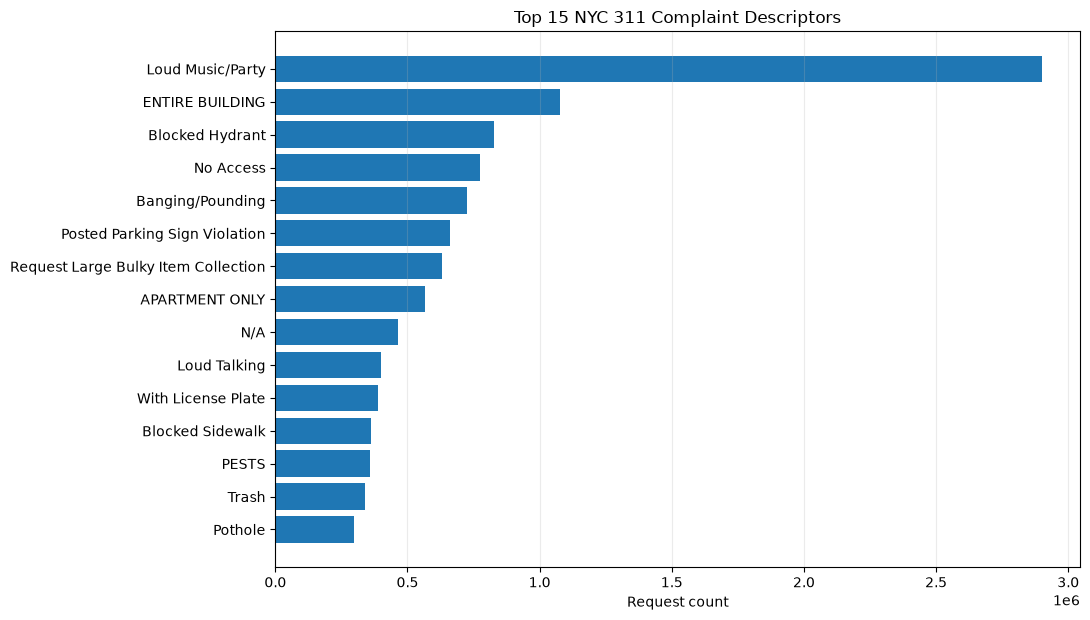

,descriptor,record_count,record_percentage
0,Loud Music/Party,2899547,13.233143
1,ENTIRE BUILDING,1078054,4.920094
2,Blocked Hydrant,828679,3.781980
3,No Access,775381,3.538735
4,Banging/Pounding,723585,3.302345
5,Posted Parking Sign Violation,662531,3.023703
6,Request Large Bulky Item Collection,632148,2.885039
7,APARTMENT ONLY,566947,2.587470
8,N/A,465710,2.125438
9,Loud Talking,401273,1.831356


In [19]:
descriptor_summary = fetch_group_summary(
    ["descriptor"],
    ["descriptor"],
    total_row_count,
)
descriptor_summary.to_csv(
    REPORT_TABLES_DIR / "descriptor_summary.csv",
    index=False,
)
save_horizontal_bar_chart(
    descriptor_summary,
    "descriptor",
    "Top 15 NYC 311 Complaint Descriptors",
    REPORT_FIGURES_DIR / "top_complaint_descriptors.png",
    top_n=15,
)

complaint_type_descriptor_summary = fetch_group_summary(
    ["complaint_type", "descriptor"],
    ["complaint_type", "descriptor"],
    total_row_count,
).drop(columns="record_percentage")
complaint_type_descriptor_summary.to_csv(
    REPORT_TABLES_DIR / "complaint_type_descriptor_summary.csv",
    index=False,
)

descriptor_summary.head(20)

## 17. Status analysis

No status is excluded. Open, pending, assigned, or other unresolved states may
require special treatment during target-feasibility analysis.

In [20]:
status_summary = fetch_group_summary(
    ["status"],
    ["status"],
    total_row_count,
)
status_summary.to_csv(
    REPORT_TABLES_DIR / "status_summary.csv",
    index=False,
)
status_summary

,status,record_count,record_percentage
0,Closed,21472032,97.995473
1,In Progress,260664,1.189636
2,Open,81978,0.374137
3,Pending,62957,0.287327
4,Assigned,24726,0.112846
5,Started,6110,0.027885
6,Unspecified,2781,0.012692
7,Cancel,1,0.000005


## 18. Borough analysis

This answers which borough values occur, how frequently each occurs, and
whether any records are missing a borough. Missing values remain explicit and
no borough values are repaired or standardized.

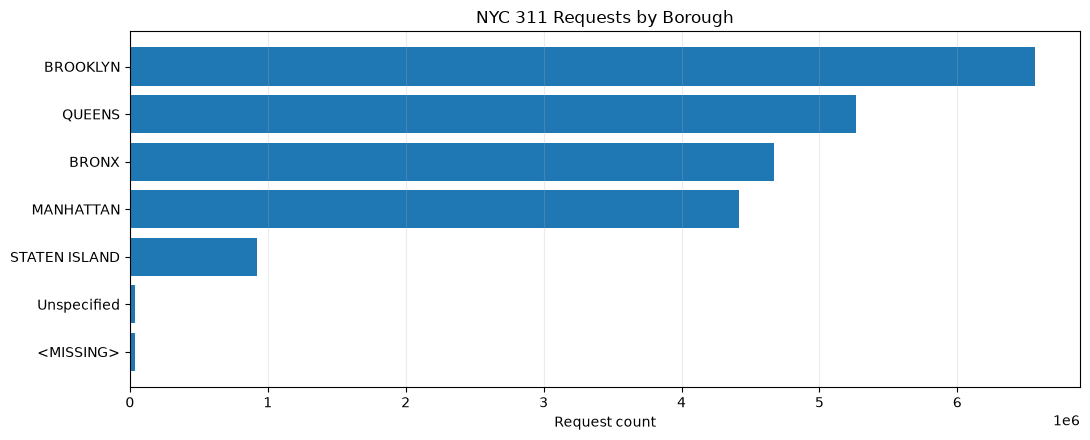

,borough,record_count,record_percentage
0,BROOKLYN,6561555,29.946056
1,QUEENS,5262063,24.015349
2,BRONX,4673206,21.327885
3,MANHATTAN,4413724,20.143644
4,STATEN ISLAND,922232,4.208943
5,Unspecified,40036,0.182719
6,<MISSING>,38433,0.175403


In [21]:
borough_summary = fetch_group_summary(
    ["borough"],
    ["borough"],
    total_row_count,
)
borough_summary.to_csv(
    REPORT_TABLES_DIR / "borough_summary.csv",
    index=False,
)
save_horizontal_bar_chart(
    borough_summary,
    "borough",
    "NYC 311 Requests by Borough",
    REPORT_FIGURES_DIR / "records_by_borough.png",
)

borough_summary

## 19. Intake-channel analysis

The intake channel describes how a complaint entered NYC 311. Values are
reported exactly as found, with missing records labelled explicitly.

In [22]:
channel_summary = fetch_group_summary(
    ["open_data_channel_type"],
    ["open_data_channel_type"],
    total_row_count,
)
channel_summary.to_csv(
    REPORT_TABLES_DIR / "channel_summary.csv",
    index=False,
)
channel_summary

,open_data_channel_type,record_count,record_percentage
0,ONLINE,9039655,41.255772
1,PHONE,6591583,30.083100
2,MOBILE,4393839,20.052892
3,UNKNOWN,1884796,8.601956
4,OTHER,1376,0.006280


## 20. Location-type analysis

The complete location-type summary is saved. Only the top twenty values are
displayed here to keep notebook output readable.

In [23]:
location_type_summary = fetch_group_summary(
    ["location_type"],
    ["location_type"],
    total_row_count,
)
location_type_summary.to_csv(
    REPORT_TABLES_DIR / "location_type_summary.csv",
    index=False,
)
location_type_summary.head(20)

,location_type,record_count,record_percentage
0,Street/Sidewalk,6230768,28.436389
1,RESIDENTIAL BUILDING,4339059,19.802883
2,<MISSING>,2911469,13.287554
3,Residential Building/House,2680018,12.231243
4,Street,1989574,9.080149
5,Sidewalk,1600401,7.304015
6,Store/Commercial,409097,1.867064
7,Park,190434,0.869115
8,Above Address,176565,0.805819
9,Club/Bar/Restaurant,173513,0.791890


## 21. Lightweight column completeness

This is a sample-level structural overview, clearly separated from the
full-dataset aggregates above. It does not impute, drop, quarantine, define
quality thresholds, or perform full schema validation. Detailed missing-value
analysis belongs in **02_schema_and_quality_analysis.ipynb**.

In [24]:
def count_unique_values(series: pd.Series) -> int:
    """Count distinct sample values, canonicalizing nested JSON structures."""
    hashable_values = series.map(
        lambda value: (
            json.dumps(value, sort_keys=True)
            if isinstance(value, (dict, list))
            else value
        )
    )
    return int(hashable_values.nunique(dropna=True))


column_summary = pd.DataFrame(
    {
        "column_name": df.columns,
        "pandas_dtype": [str(dtype) for dtype in df.dtypes],
        "non_null_count": df.notna().sum().to_numpy(),
        "missing_count": df.isna().sum().to_numpy(),
        "missing_percentage": (df.isna().mean() * 100).to_numpy(),
        "unique_count": [count_unique_values(df[column]) for column in df.columns],
    }
).sort_values(
    ["missing_percentage", "column_name"],
    ascending=[False, True],
    ignore_index=True,
)
column_summary.to_csv(
    REPORT_TABLES_DIR / "column_summary.csv",
    index=False,
)
column_summary

,column_name,pandas_dtype,non_null_count,missing_count,missing_percentage,unique_count
0,due_date,float64,0,7000,100.000000,0
1,road_ramp,str,3,6997,99.957143,1
2,taxi_company_borough,str,3,6997,99.957143,2
3,bridge_highway_direction,str,6,6994,99.914286,6
4,bridge_highway_name,str,19,6981,99.728571,14
5,bridge_highway_segment,str,19,6981,99.728571,7
6,taxi_pick_up_location,str,31,6969,99.557143,27
7,vehicle_type,str,93,6907,98.671429,5
8,facility_type,str,102,6898,98.542857,2
9,descriptor_2,str,677,6323,90.328571,123


## 22. Final findings and conclusions

The conclusions below are assembled from the computed full-dataset summaries
and explicitly identified sample-level observations. They do not define a
target, select features, clean records, or make modelling decisions.

In [25]:
agency_names = agency_summary["Agency Name"].astype(str).drop_duplicates().tolist()
status_values = status_summary["status"].astype(str).tolist()
borough_values = borough_summary["borough"].astype(str).tolist()
channel_values = channel_summary["open_data_channel_type"].astype(str).tolist()
due_date_row = date_coverage.loc[date_coverage["column"] == "due_date"].iloc[0]
due_date_non_null = int(due_date_row["non_null_count"])
due_date_missing_percentage = float(due_date_row["missing_percentage"])

is_broad_extract = len(agency_codes) > 1 and len(complaint_categories) > 2
scope_description = (
    "a broad NYC 311 extract spanning multiple agencies and complaint categories"
    if is_broad_extract
    else "a narrowly scoped NYC 311 extract"
)
partial_year_statement = (
    f"{maximum_created_date.year} is a partial year ending on "
    f"{maximum_created_date.date().isoformat()} and should not be compared "
    "directly with full calendar years."
    if latest_year_is_partial
    else f"{maximum_created_date.year} appears complete through year end."
)
due_date_statement = (
    "Due Date is entirely missing."
    if due_date_non_null == 0
    else (
        f"Due Date is present for {due_date_non_null:,} records and is "
        f"missing for {due_date_missing_percentage:.2f}% of records."
    )
)

conclusion_markdown = f"""
### Computed conclusions

- **Dataset dimensions:** {total_row_count:,} rows and {len(SELECTED_COLUMNS):,}
  selected API columns at retrieval time.
- **Dataset grain:** Each row appears to represent one NYC 311 service request;
  unique_key appears to be its identifier.
- **Creation-date range:** {minimum_created_date.date().isoformat()} through
  {maximum_created_date.date().isoformat()}.
- **Latest-year coverage:** {partial_year_statement}
- **Agencies ({len(agency_codes):,}):** {", ".join(agency_names)}.
- **Complaint categories ({len(complaint_categories):,}):**
  {", ".join(complaint_categories)}.
- **Descriptor values:** {len(descriptor_summary):,}, including the explicit
  missing-value group when present.
- **Statuses:** {", ".join(status_values)}.
- **Borough values:** {", ".join(borough_values)}.
- **Intake channels:** {", ".join(channel_values)}.
- **Due Date completeness:** {due_date_statement}
- **Scope assessment:** The supplied unfiltered endpoint is
  {scope_description}; it is not the narrow DOT-only CSV described in the
  earlier expectation.
- **Row-level inspection boundary:** pandas-inferred dtypes and lightweight
  completeness use {len(df):,} deterministic records across creation years;
  categorical and time summaries use full-dataset API aggregates.

### Investigate next

1. Validate required fields, identifiers, missingness, date parsing, timestamp
   consistency, and schema drift in **02_schema_and_quality_analysis.ipynb**.
2. Decide a limited agency, complaint-category, and time scope before modelling;
   the current endpoint is too broad to treat all operational processes as one.
3. Assess target availability, unresolved/censored requests, and Due Date
   suitability in **03_target_feasibility.ipynb**.
4. Review prediction-time availability of closed_date, status,
   resolution_description, and resolution_action_updated_date to prevent
   leakage.
"""

display(Markdown(conclusion_markdown))


### Computed conclusions

- **Dataset dimensions:** 21,911,249 rows and 44
  selected API columns at retrieval time.
- **Dataset grain:** Each row appears to represent one NYC 311 service request;
  unique_key appears to be its identifier.
- **Creation-date range:** 2020-01-01 through
  2026-07-23.
- **Latest-year coverage:** 2026 is a partial year ending on 2026-07-23 and should not be compared directly with full calendar years.
- **Agencies (21):** New York City Police Department, Department of Housing Preservation and Development, Department of Sanitation, Department of Transportation, Department of Environmental Protection, Department of Parks and Recreation, Department of Buildings, Department of Health and Mental Hygiene, Department of Homeless Services, Taxi and Limousine Commission, Economic Development Corporation, Department of Consumer and Worker Protection, Mayor's Office of Special Enforcement, Department of Consumer Affairs, Department of Education, Office of the Sheriff, Department for the Aging, Office of Technology and Innovation, Department of Information Technology and Telecommunications, HIQA, Operations Unit - Department of Homeless Services, 3-1-1.
- **Complaint categories (272):**
  Illegal Parking, Noise - Residential, HEAT/HOT WATER, Noise - Street/Sidewalk, Blocked Driveway, UNSANITARY CONDITION, Request Large Bulky Item Collection, Street Condition, Water System, Noise - Vehicle, PLUMBING, Noise - Commercial, Abandoned Vehicle, PAINT/PLASTER, Noise, Street Light Condition, Derelict Vehicles, Traffic Signal Condition, DOOR/WINDOW, Dirty Condition, WATER LEAK, Damaged Tree, General Construction/Plumbing, Missed Collection, Rodent, Homeless Person Assistance, Encampment, Non-Emergency Police Matter, Sewer, GENERAL, Noise - Helicopter, ELECTRIC, Illegal Dumping, Sidewalk Condition, FLOORING/STAIRS, Consumer Complaint, Maintenance or Facility, APPLIANCE, Overgrown Tree/Branches, Building/Use, Illegal Fireworks, Elevator, For Hire Vehicle Complaint, Graffiti, New Tree Request, Drug Activity, Lead, Snow or Ice, Obstruction, Missed Collection (All Materials), Vendor Enforcement, SAFETY, Food Establishment, Dirty Conditions, NonCompliance with Phased Reopening, Dead/Dying Tree, Air Quality, Sanitation Condition, Root/Sewer/Sidewalk Condition, Residential Disposal Complaint, Noise - Park, Animal-Abuse, Panhandling, Dead Animal, Traffic, Indoor Air Quality, Taxi Complaint, Curb Condition, Lost Property, Street Sweeping Complaint, Broken Parking Meter, Street Sign - Damaged, Electronics Waste Appointment, Real Time Enforcement, Outdoor Dining, Animal in a Park, Violation of Park Rules, Illegal Tree Damage, Water Conservation, Street Sign - Missing, Mobile Food Vendor, Highway Condition, Special Projects Inspection Team (SPIT), Drinking, Street Sign - Dangling, Emergency Response Team (ERT), Boilers, Plumbing, Illegal Posting, Litter Basket Request, Food Poisoning, Smoking, Bike/Roller/Skate Chronic, Homeless Street Condition, Unsanitary Animal Pvt Property, Smoking or Vaping, Sanitation Worker or Vehicle Complaint, Electrical, Hazardous Materials, Other Enforcement, Noise - House of Worship, Commercial Disposal Complaint, ELEVATOR, Abandoned Bike, Day Care, Water Quality, Unleashed Dog, Snow, Asbestos, Dumpster Complaint, School Maintenance, Lot Condition, Standing Water, Unsanitary Pigeon Condition, Bus Stop Shelter Complaint, Urinating in Public, Vaccine Mandate Non-Compliance, COVID-19 Non-essential Construction, Litter Basket Complaint, Construction Lead Dust, Non-Residential Heat, OUTSIDE BUILDING, Industrial Waste, Overflowing Litter Baskets, Wood Pile Remaining, Taxi Report, Vending, Indoor Sewage, Vacant Lot, Litter Basket / Request, Investigations and Discipline (IAD), Mass Gathering Complaint, Cannabis Retailer, Illegal Animal Kept as Pet, Water Leak, Storm, Derelict Bicycle, Harboring Bees/Wasps, Sewer Maintenance, BEST/Site Safety, Snow Removal, Sweeping/Missed, For Hire Vehicle Report, Home Delivered Meal - Missed Delivery, Uprooted Stump, Mosquitoes, Paint/Plaster, Construction Safety Enforcement, E-Scooter, Private or Charter School Reopening, Mold, Ferry Inquiry, Bridge Condition, Drinking Water, Green Taxi Complaint, Heat/Hot Water, Face Covering Violation, Disorderly Youth, Ferry Complaint, Beach/Pool/Sauna Complaint, Unsanitary Condition, Door/Window, Bike/Roller/Skate, Tattooing, Bus Stop Shelter Placement, Bike Rack, LinkNYC, Scaffold Safety, Bike Rack Condition, Plant, Poison Ivy, Pet Shop, AHV Inspection Unit, Seasonal Collection, Adopt-A-Basket, Highway Sign - Damaged, Flooring/Stairs, DEP Street Condition, Recycling Enforcement, Posting Advertisement, General, Illegal Animal Sold, Animal Facility - No Permit, Unsanitary Animal Facility, Taxi Compliment, Cranes and Derricks, Appliance, Sweeping/Inadequate, Found Property, Collection Truck Noise, Recycling Basket Complaint, Public Payphone Complaint, Municipal Parking Facility, Water Maintenance, Incorrect Data, Highway Sign - Missing, Pet Sale, Special Natural Area District (SNAD), Safety, Electric, Institution Disposal Complaint, Building Drinking Water Tank, Public Toilet, Bench, Squeegee, Private School Vaccine Mandate Non-Compliance, Green Taxi Report, Tobacco or Non-Tobacco Sale, Special Operations, Homeless Encampment, Highway Sign - Dangling, Borough Office, Lifeguard, Dept of Investigations, Cooling Tower, X-Ray Machine/Equipment, Window Guard, Water Drainage, Peeling Paint, Radioactive Material, Unstable Building, Dispatched Taxi Complaint, Building Condition, Taxi Licensee Complaint, Sweeping/Missed-Inadequate, Bottled Water, Retailer Complaint, Calorie Labeling, FHV Licensee Complaint, SNW, Wayfinding, Transfer Station Complaint, Unspecified, Boiler, DEP Highway Condition, Oil or Gas Spill, Tunnel Condition, Building Marshal's Office, Miscellaneous Categories, Overflowing Recycling Baskets, DEP Sidewalk Condition, Internal Code, Tanning, Building Marshals office, DSNY Internal, Foam Ban Enforcement, Leaning Bar, Home Delivered Meal Complaint, Executive Inspections, ZTESTINT, DOB Posted Notice or Order, Ferry Permit, DSNY Spillage, SRDE, Employee Behavior, Trans Fat, Facades, SRGOVG, Dispatched Taxi Compliment, Electronics Waste, Facade Insp Safety Pgm, Unlicensed Dog, Outside Building, Stalled Sites, DEP Bridge Condition, Quality of Life, Trapping Pigeon, Change Collection Schedule, Forensic Engineering, ASBESTOS, MOLD, Sustainability Enforcement.
- **Descriptor values:** 1,295, including the explicit
  missing-value group when present.
- **Statuses:** Closed, In Progress, Open, Pending, Assigned, Started, Unspecified, Cancel.
- **Borough values:** BROOKLYN, QUEENS, BRONX, MANHATTAN, STATEN ISLAND, Unspecified, <MISSING>.
- **Intake channels:** ONLINE, PHONE, MOBILE, UNKNOWN, OTHER.
- **Due Date completeness:** Due Date is present for 76,953 records and is missing for 99.65% of records.
- **Scope assessment:** The supplied unfiltered endpoint is
  a broad NYC 311 extract spanning multiple agencies and complaint categories; it is not the narrow DOT-only CSV described in the
  earlier expectation.
- **Row-level inspection boundary:** pandas-inferred dtypes and lightweight
  completeness use 7,000 deterministic records across creation years;
  categorical and time summaries use full-dataset API aggregates.

### Investigate next

1. Validate required fields, identifiers, missingness, date parsing, timestamp
   consistency, and schema drift in **02_schema_and_quality_analysis.ipynb**.
2. Decide a limited agency, complaint-category, and time scope before modelling;
   the current endpoint is too broad to treat all operational processes as one.
3. Assess target availability, unresolved/censored requests, and Due Date
   suitability in **03_target_feasibility.ipynb**.
4. Review prediction-time availability of closed_date, status,
   resolution_description, and resolution_action_updated_date to prevent
   leakage.


## Scope confirmation

This notebook is descriptive only. It does not modify source records, clean or
remove rows, fill missing values, rename the raw dataframe columns, create the
prediction target, select final features, split data, train models, perform
anomaly detection, or implement the production API ingestion pipeline.